# 6.2 Rejection Sampling

In [1]:
import sys
sys.path.insert(0, "../")
from plotting import *
setup_plotting()



## Rejection Sampling

What do we do if we want to generate samples of a random variable with density ff and there isn’t a built in function for doing this? If the random variable is of a reasonably low dimension (less than 10?), then *rejection sampling* is a plausible general approach.

The idea of rejection sampling is that although we cannot easily sample from f, there exists another density g, like a Normal distribution or perhaps a t-distribution, from which it is easy for us to sample (because there’s a built in function or someone else wrote a nice function). Then we can sample from g directly and then “reject” the samples in a strategic way to make the resulting “non-rejected” samples look like they came from f. The density g will be referred to as the “candidate density” and f will be the “target density”.

In order to use the rejections sampling algorithm, we must first ensure that the support of f is a subset of the support of g. If $\mathcal{X}_f$ is the support of f and $\mathcal{X}_g$ is the support of g, then we must have $\mathcal{X}_f \subset \mathcal{X}_g$. This makes sense: if there's a region of the support of f that g can never touch, then that area will never get sampled. In addition, we must assume that
$c=\sup_{x\in\mathcal{X}_f}\frac{f(x)}{g(x)}<\infty$
and that we can calculate c. The easiest way to satisfy this assumption is to make sure that g has heavier tails than f. We cannot have that g decreases at a faster rate than f in the tails or else rejection sampling will not work.

### The Algorithm

The rejection sampling algorithm for drawing a sample from the target density f is then

1. Simulate $U \sim \text{Unif}(0,1)$.
2. Simulate a candidate $X \sim g$ from the candidate density
3. If
$U\leq\frac{f(X)}{cg(X)}$
then “accept” the candidate X. Otherwise, “reject” X and go back to the beginning.

The algorithm can be repeated until the desired number of samples from the target density f has been accepted.

As a simple example, suppose we wanted to generate samples from a N(0,1) density. We could use the t2 distribution as our candidate density as it has heavier tails than the Normal. Plotting those two densities, along with a sample from the t2 density gives us the picture below.

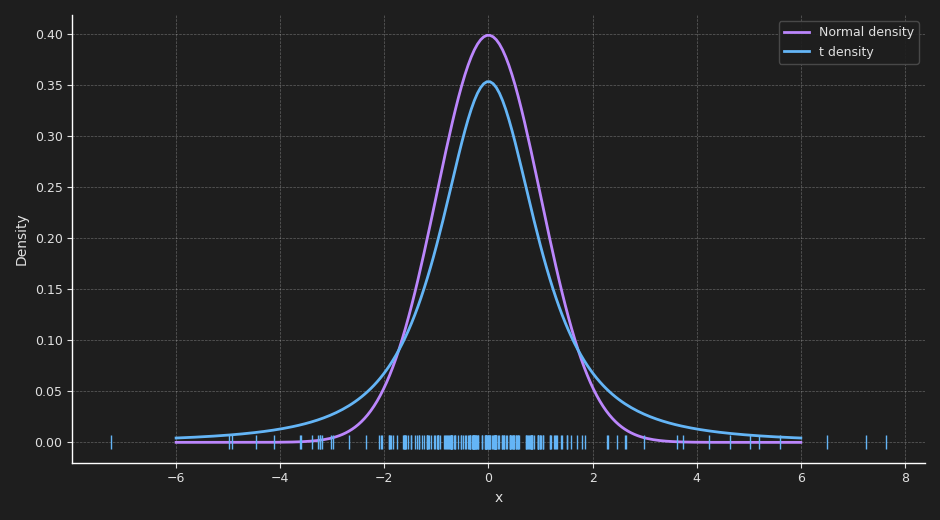

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
rng = np.random.default_rng(20171204)
xs = np.linspace(-6, 6, 200)
fig, ax = plt.subplots(figsize=FIGSIZE_DEFAULT)
ax.plot(xs, stats.norm.pdf(xs), label='Normal density')
ax.plot(xs, stats.t.pdf(xs, 2), color=C['blue'], label='t density')
ax.set_xlabel('x')
ax.set_ylabel('Density')
ax.legend(loc='upper right')
x = rng.standard_t(2, size=200)
ax.plot(x, np.zeros_like(x), '|', color=C['blue'], markersize=10)
plt.tight_layout()

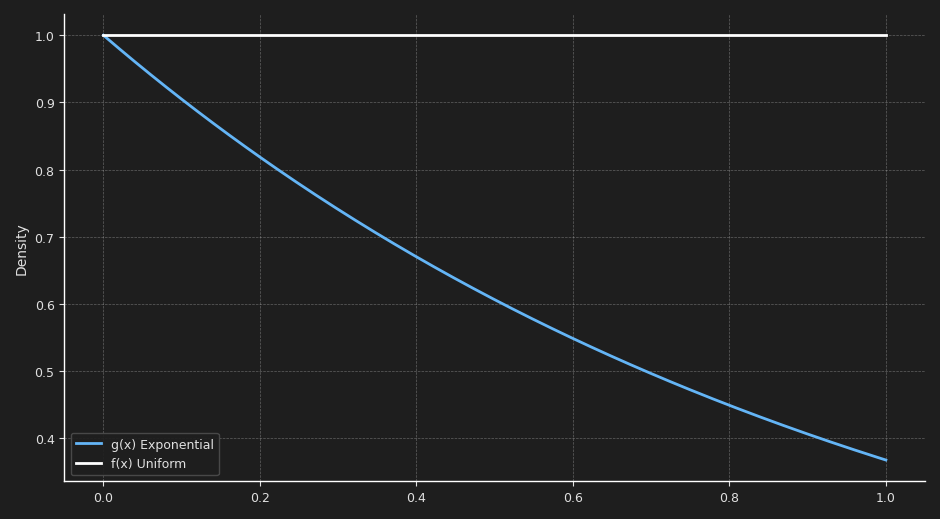

In [3]:
xs = np.linspace(0, 1, 200)
fig, ax = plt.subplots(figsize=FIGSIZE_DEFAULT)
ax.plot(xs, stats.expon.pdf(xs, scale=1), color=C['blue'], label='g(x) Exponential')
ax.plot([0, 1], [1, 1], color='white', label='f(x) Uniform')
ax.set_ylabel('Density')
ax.legend(loc='lower left')
plt.tight_layout()

Given what we know about the standard Normal density, most of the samples should be between -3 and +3, except perhaps in very large samples (this is a sample of size 200). From the picture, there are samples in the range of 4–6. In order to transform the t2 samples into N(0,1) samples, we will need to reject many of the samples out in the tail. On the other hand, there are two *few* samples in the range of [-2,2] and so we will have to disproportionaly accept samples in that range until it represents the proper N(0,1) density.

Before we move on, it’s worth noting that the rejection sampling method requires that we can *evaluate* the target density f. That is how we compute the rejection/acceptance ratio in Step 2. In most cases, this will not be a problem.

### Properties of Rejection Sampling

One property of the rejection sampling algorithm is that the number of draws we need to take from the candidate density g before we accept a candidate is a geometric random variable with success probability 1/c. We can think of the decision to accept or reject a candidate as a sequence of iid coin flips that has a specific probability of coming up “heads” (i.e.&nbsp;being accepted). That probability is 1/c and we can calculate that as follows.



$$
\mathbb{P}(X \text{ accepted})=\mathbb{P}\left(U\leq\frac{f(X)}{c\,g(X)}\right)=\int\mathbb{P}\left(U\leq\frac{f(x)}{c\,g(x)}\mid X=x\right)g(x)\,dx=\int\frac{f(x)}{c\,g(x)}g(x)\,dx=\frac{1}{c}
$$



This property of rejection sampling has implications for how we choose the candidate density g. In theory, any density can be chosen as the candidate as long as its support includes the support of f. However, in practice we will want to choose g so that it matches f as closely as possible. As a rule of thumb, candidates g that match f closely will have smaller values of c and thus will accept candidates with higher probability. We want to avoid large values of c because large values of c lead to an algorithm that rejects a lot of candidates and has lower efficiency.

In the example above with the Normal distribution and the t2 distribution, the ratio f(x)/g(x) was maximized at x=1 (or x=-1) and so the value of c for that setup was 1.257, which implies an acceptance probability of about 0.8. Suppose however, that we wanted to simulate from a Uniform(0,1) density and we used an Exponential(1) as our candidate density. The plot of the two densities looks as follows.

In [4]:
rng = np.random.default_rng(20171204)
N = 500
y_tilde = np.zeros(N, dtype=bool)  # Binary accept/reject for "true" algorithm
y = np.zeros(N, dtype=bool)  # Binary accept/reject for ESUP
log_c_true = stats.norm.logpdf(1) - stats.t.logpdf(1, 2)
log_chat = np.zeros(N + 1)
log_chat[0] = np.log(1.0001)  # Starting c value
for i in range(N):
    u = rng.uniform(0, 1)
    x = rng.standard_t(2)
    r_true = stats.norm.logpdf(x) - stats.t.logpdf(x, 2) - log_c_true
    rhat = stats.norm.logpdf(x) - stats.t.logpdf(x, 2) - log_chat[i]
    y_tilde[i] = np.log(u) <= r_true
    y[i] = np.log(u) <= rhat
    log_chat[i+1] = max(log_chat[i], 
                         stats.norm.logpdf(x) - stats.t.logpdf(x, 2))

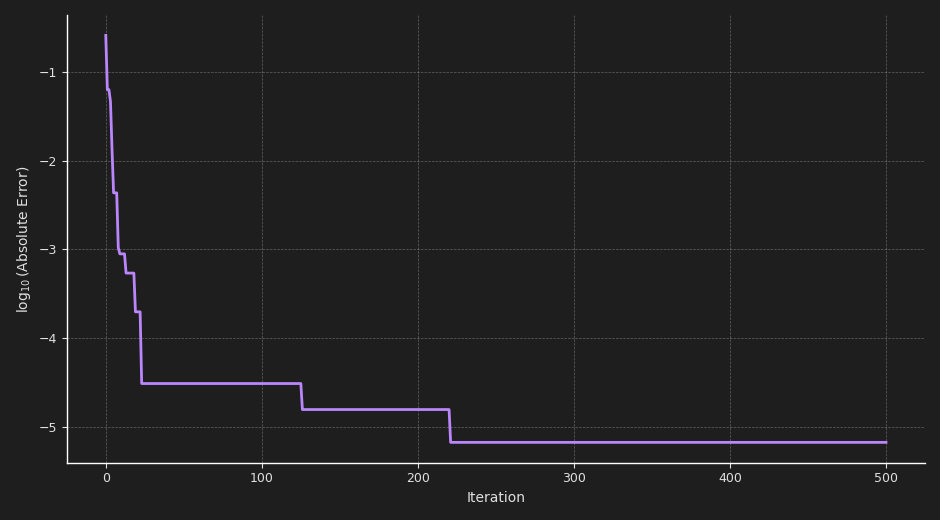

In [5]:
c_true = np.exp(log_c_true)
chat = np.exp(log_chat)
fig, ax = plt.subplots(figsize=FIGSIZE_DEFAULT)
ax.plot(np.log10(np.abs(chat - c_true)))
ax.set_xlabel('Iteration')
ax.set_ylabel(r'$\log_{10}$(Absolute Error)')
plt.tight_layout()

Here, the ratio of f(x)/g(x) is maximized at x=1 and so the value of c is 2.718 which implies an acceptance probablity of about 0.37. While running the rejection sampling algorithm in this way to produce Uniform random variables will still work, it will be very inefficient.

We can now show that the distribution of the accepted values from the rejection sampling algorithm above follows the target density f. We can do this by calculating the *distribution function* of the accepted values and show that this is equal to $F(t) = \int_{-\infty}^t f(x)\,dx$.

$$\begin{eqnarray*}
\mathbb{P}(X\leq t\mid X~\text{accepted})
& = &
\frac{\mathbb{P}(X\leq t, X~\text{accepted})}{\mathbb{P}(X~\text{accepted})}\\
& = &
\frac{\mathbb{P}(X\leq t, X~\text{accepted})}{1/c}\\
& = &
c\,
\mathbb{E}_g
\mathbb{E}\left[
\left.\mathbf{1}\{x\leq t\}\mathbf{1}\left\{U\leq\frac{f(x)}{c\,g(x)}\right\}\right| X = x
\right]\\
& = &
c\,\mathbb{E}_g\left[\mathbf{1}\{X\leq t\}\frac{f(X)}{c\,g(X)}\right]\\
& = &
\int_{-\infty}^t f(x)\,dx\\
& = & F(t)
\end{eqnarray*}

$$

This shows that the distribution function of the candidate values, given that they are accepted, is equal to the distribution function corresponding to the target density.

A few further notes:

1. We only need to know f and g up to a constant of proportionality. In many applications we will not know the normalizing constant for these densities, but we do not need them. That is, if $f(x) = k_1 f^\star(x)$ and $g(x) = k_2 g^\star(x)$, we can proceed with the algorithm using $f^\star$ and $g^\star$ even if we do not know the values of k1 and k2.
2. Any number $c' \geq c$ will work in the rejection sampling algorithm, but the algorithm will be less efficient.
3. Throughout the algorithm, operations can (and should!) be done on a log scale.
4. The higher the dimension of f and g, the less efficient the rejection sampling algorithm will be.
5. Whether $c=\infty$ or not depends on the tail behavior of the the densities f and g. If $g(x)\downarrow 0$ faster than $f(x)\downarrow 0$ as $x\rightarrow\infty$, then $f(x)/g(x) \uparrow \infty$.

### Empirical Supremum Rejection Sampling

What if we cannot calculate $c = \sup_{x\in\mathcal{X}_f}\frac{f(x)}{g(x)}$ or are simply too lazy to do so? Fear not, because it turns out we almost never have to do so. A slight modification of the standard rejection sampling algorithm will allow us to *estimate* c while also sampling from the target density f. The tradeoff (there is always a tradeoff!) is that we must make a more stringent assumption about c, mainly that it is achievable. That is, there exists some value $x_c \in \mathcal{X}_f$ such that $f(x_c)/g(x_c)$ is *equal* to $\sup_{x\in\mathcal{X}_f}\frac{f(x)}{g(x)}$. The modified algorithm is the empirical supremum rejection sampling algorithm of Caffo, Booth, and Davison.

First we must choose some starting value of $c$, call it $\hat{c}$, such that $\hat{c} > 1$. The algorithm goes as follows.

1. Draw $U\sim\text{Unif}(0,1)$
2. Draw $X\sim g$, the candidate density
3. Accept $X$ if $U \leq f(X)/(\hat{c}\, g(X))$, otherwise reject $X$
4. Let $\hat{c}^\star = \max\{\hat{c},\, f(X)/g(X)\}$
5. Update $\hat{c} = \hat{c}^\star$
6. Goto Step 1

From the algorithm we can see that at each iteration, we get more information about the ratio $f(X)/g(X)$ and can update our estimate of $c$ accordingly.

Specifically, Caffo, Booth, and Davison showed that $\mathbb{P}(Y_i\neq\tilde{Y}_i \text{ infinitely often})=0$. Let $\gamma = \min_i\{x_i = x_c\}$, where $x_i \sim g$. So $\gamma$ is the first time that we see the value $x_c$ as we are sampling candidates $x_i$ from $g$. The probability that we sample $x_c$ is $g(x_c)$ (recall that $g$ is assumed to be discrete here) and so $\gamma$ has a Geometric distribution with success probability $g(x_c)$. Once we observe $x_c$, the ESUP algorithm and the standard rejection sampling algorithms converge and are identical.

From here, we can use the coupling inequality, which tells us that
$\mathbb{P}(Y_i\neq\tilde{Y}_i) \leq \mathbb{P}(\gamma \geq i)$.
Given that $\gamma \sim \text{Geometric}(g(x_c))$, we know that
$$P(\gamma \geq i) = (1 - g(x_c))^{i-1}.$$

This then implies that
$$\sum_{i=1}^\infty \mathbb{P}(Y_i\ne\tilde{Y}_i) < \infty$$
which, by the [Borel-Cantelli lemma](https://en.wikipedia.org/wiki/Borel–Cantelli_lemma), implies that 

$$
\mathbb{P}(Y_i\neq\tilde{Y}_i \text{ infinitely often})=0
$$

Therefore, eventually the sequences $Y_i$ and $\tilde{Y}_i$ must converge and at that point the ESUP algorithm will be identical to the rejection sampling algorithm.

In practice, we will not know exactly when the ESUP algorithm has converged to the standard rejection sampling algorithm. However, Caffo, Booth, and Davison report that the convergence is generally fast. Therefore, a reasonable approach might be to discard the first several accepted values (e.g.&nbsp;a "burn in") and then use the remaining values.